##### LLM Workflow

In [16]:
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from IPython.display import display, Image


In [22]:
model = ChatGoogleGenerativeAI(model="gemini-2.5-flash-lite")

In [8]:
class LLMstate(TypedDict):
    question: str
    answer: str

In [23]:
def QA_bot(state: LLMstate) -> LLMstate:
    question = state['question']
    answer = model.invoke(question)

    state['answer'] = answer.content
    return state


In [19]:
graph = StateGraph(LLMstate)

graph.add_node('Q&A_bot', QA_bot)

graph.add_edge(START, 'Q&A_bot')
graph.add_edge('Q&A_bot', END)

workflow = graph.compile()

In [21]:
initial_state = {'question': 'what is open knowledge Format in short?'}
final_state = workflow.invoke(initial_state)
print(final_state['answer'])

In short, **Open Knowledge Format** refers to data, information, or content that is **freely accessible, usable, and shareable by anyone, without significant restrictions.**

Think of it as information that is **"open for everyone to use and build upon."**


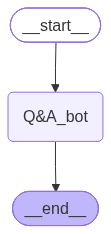

In [17]:
display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))